<a href="https://colab.research.google.com/github/LaibaSaleem01/categorical-encoding-practice/blob/main/categorical_encoding_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cell 1: Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [2]:
# Cell 2: Generate a simple dataset

# Generate 50 ages around the average age of 30
ages = np.random.normal(
    loc=30,
    scale=5,
    size=50
)

# Round the ages
ages = np.round(ages)

# Add some unrealistic outliers
ages = np.append(ages, [70, 80, 90])

# Generate cities
cities = np.random.choice(
    ["Islamabad", "Lahore", "Karachi"],
    size=len(ages)
)

# Create the dataset
df = pd.DataFrame({
    "Age": ages,
    "City": cities
})

df.head(10)

,Age,City
0,32.0,Islamabad
1,29.0,Islamabad
2,33.0,Karachi
3,38.0,Islamabad
4,29.0,Islamabad
5,29.0,Islamabad
6,38.0,Karachi
7,34.0,Islamabad
8,28.0,Islamabad
9,33.0,Karachi


In [3]:
# Cell 3: Check the dataset

print("Dataset shape:", df.shape)

print("\nBasic information:")
print(df.info())

print("\nNumerical summary:")
print(df.describe())

Dataset shape: (53, 2)

Basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Age     53 non-null     float64
 1   City    53 non-null     object 
dtypes: float64(1), object(1)
memory usage: 980.0+ bytes
None

Numerical summary:
             Age
count  53.000000
mean   31.754717
std    12.927171
min    20.000000
25%    26.000000
50%    29.000000
75%    32.000000
max    90.000000


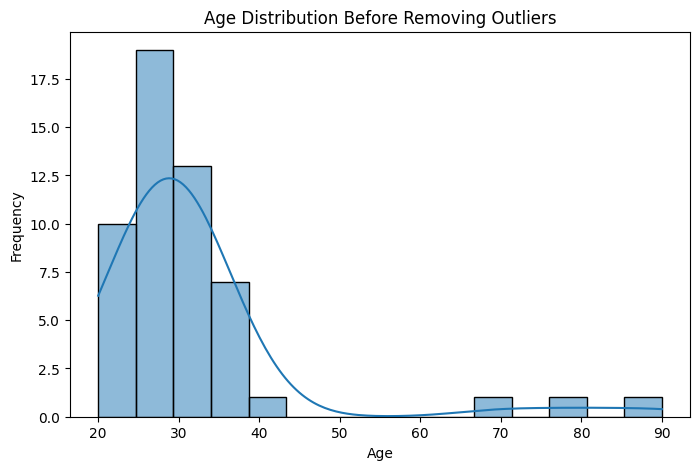

In [4]:
# Cell 4: Bell curve before cleaning

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution Before Removing Outliers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

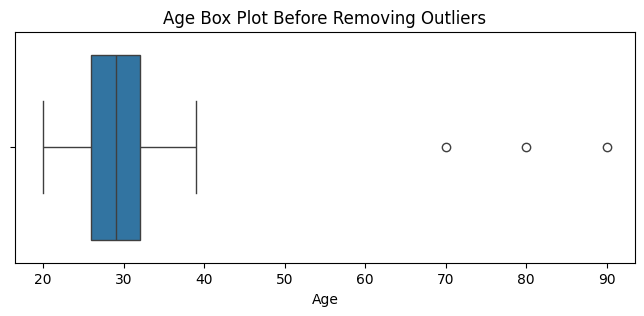

In [5]:
# Cell 5: Box plot before cleaning

plt.figure(figsize=(8, 3))

sns.boxplot(x=df["Age"])

plt.title("Age Box Plot Before Removing Outliers")
plt.xlabel("Age")

plt.show()

In [6]:
# Cell 6: Find the outlier limits using IQR

# Find the first quartile
Q1 = df["Age"].quantile(0.25)

# Find the third quartile
Q3 = df["Age"].quantile(0.75)

# Calculate the interquartile range
IQR = Q3 - Q1

# Calculate the lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Q1: 26.0
Q3: 32.0
IQR: 6.0
Lower limit: 17.0
Upper limit: 41.0


In [7]:
# Cell 7: Display the outliers

outliers = df[
    (df["Age"] < lower_limit) |
    (df["Age"] > upper_limit)
]

print("Outliers found:")

outliers

Outliers found:


,Age,City
50,70.0,Karachi
51,80.0,Lahore
52,90.0,Lahore


In [8]:
# Cell 8: Remove the outliers

clean_df = df[
    (df["Age"] >= lower_limit) &
    (df["Age"] <= upper_limit)
].copy()

print("Rows before cleaning:", len(df))
print("Rows after cleaning:", len(clean_df))

clean_df.head()

Rows before cleaning: 53
Rows after cleaning: 50


,Age,City
0,32.0,Islamabad
1,29.0,Islamabad
2,33.0,Karachi
3,38.0,Islamabad
4,29.0,Islamabad


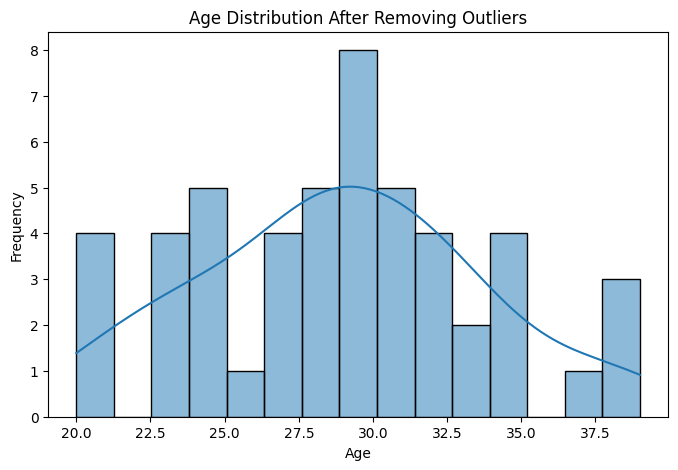

In [9]:
# Cell 9: Bell curve after removing outliers

plt.figure(figsize=(8, 5))

sns.histplot(
    clean_df["Age"],
    bins=15,
    kde=True
)

plt.title("Age Distribution After Removing Outliers")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

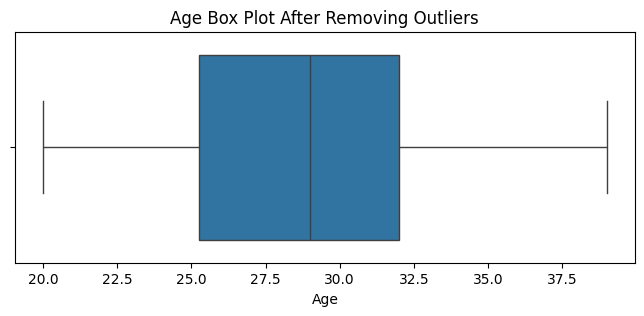

In [10]:
# Cell 10: Box plot after removing outliers

plt.figure(figsize=(8, 3))

sns.boxplot(x=clean_df["Age"])

plt.title("Age Box Plot After Removing Outliers")
plt.xlabel("Age")

plt.show()

In [11]:
# Cell 11: Check the categorical City column

print(clean_df["City"].value_counts())

City
Karachi      23
Islamabad    19
Lahore        8
Name: count, dtype: int64


In [12]:
# Cell 12: Create separate copies

# Create separate copies of the same cleaned dataset

one_hot_df = clean_df.copy()
label_df = clean_df.copy()
frequency_df = clean_df.copy()

In [13]:
# Cell 13: Apply one-hot encoding

one_hot_df = pd.get_dummies(
    one_hot_df,
    columns=["City"],
    dtype=int
)

print("One-Hot Encoded Data:")

one_hot_df.head(10)

One-Hot Encoded Data:


,Age,City_Islamabad,City_Karachi,City_Lahore
0,32.0,1,0,0
1,29.0,1,0,0
2,33.0,0,1,0
3,38.0,1,0,0
4,29.0,1,0,0
5,29.0,1,0,0
6,38.0,0,1,0
7,34.0,1,0,0
8,28.0,1,0,0
9,33.0,0,1,0


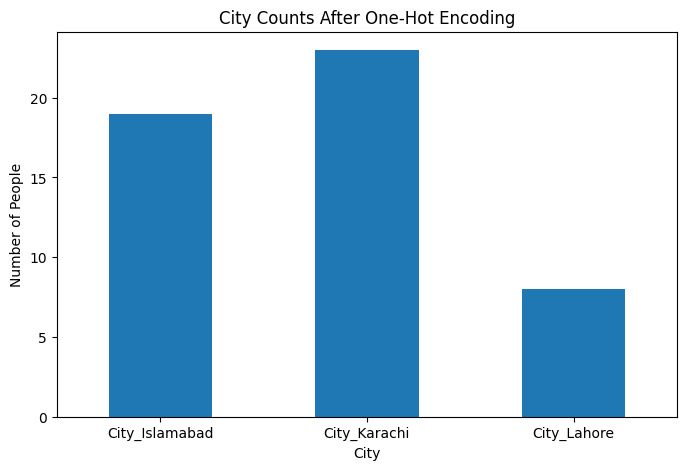

In [14]:
# Cell 14: Visualize one-hot encoding

city_columns = [
    "City_Islamabad",
    "City_Karachi",
    "City_Lahore"
]

city_counts = one_hot_df[city_columns].sum()

city_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("City Counts After One-Hot Encoding")
plt.xlabel("City")
plt.ylabel("Number of People")
plt.xticks(rotation=0)

plt.show()

In [15]:
# Cell 15: Apply label encoding

from sklearn.preprocessing import LabelEncoder

# Create the encoder
label_encoder = LabelEncoder()

# Convert city names into numbers
label_df["City_Encoded"] = label_encoder.fit_transform(
    label_df["City"]
)

print("Label Encoded Data:")

label_df.head(10)

Label Encoded Data:


,Age,City,City_Encoded
0,32.0,Islamabad,0
1,29.0,Islamabad,0
2,33.0,Karachi,1
3,38.0,Islamabad,0
4,29.0,Islamabad,0
5,29.0,Islamabad,0
6,38.0,Karachi,1
7,34.0,Islamabad,0
8,28.0,Islamabad,0
9,33.0,Karachi,1


In [16]:
# Cell 16: Display the label encoding mapping

label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print("Label Encoding Mapping:")

print(label_mapping)

Label Encoding Mapping:
{'Islamabad': np.int64(0), 'Karachi': np.int64(1), 'Lahore': np.int64(2)}


In [17]:
# Cell 17: Apply frequency encoding

# Calculate how frequently each city appears

city_frequency = frequency_df[
    "City"
].value_counts(normalize=True)

print("City Frequencies:")

print(city_frequency)

City Frequencies:
City
Karachi      0.46
Islamabad    0.38
Lahore       0.16
Name: proportion, dtype: float64


In [18]:
# Replace each city with its frequence

frequency_df["City_Frequency"] = frequency_df[
    "City"
].map(city_frequency)

print("Frequency Encoded Data:")

frequency_df.head(10)

Frequency Encoded Data:


,Age,City,City_Frequency
0,32.0,Islamabad,0.38
1,29.0,Islamabad,0.38
2,33.0,Karachi,0.46
3,38.0,Islamabad,0.38
4,29.0,Islamabad,0.38
5,29.0,Islamabad,0.38
6,38.0,Karachi,0.46
7,34.0,Islamabad,0.38
8,28.0,Islamabad,0.38
9,33.0,Karachi,0.46


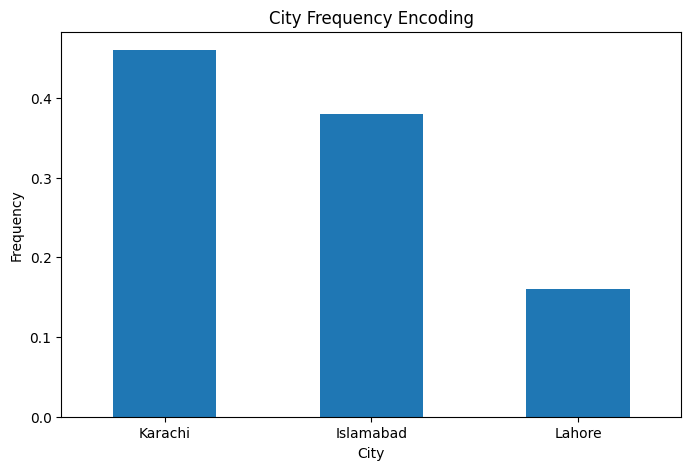

In [19]:
# Cell 18: Visualize frequency encoding

city_frequency.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("City Frequency Encoding")
plt.xlabel("City")
plt.ylabel("Frequency")
plt.xticks(rotation=0)

plt.show()

In [20]:
# Cell 19: Compare the three final datasets

print("ONE-HOT ENCODING")
display(one_hot_df.head(10))

print("\nLABEL ENCODING")
display(label_df.head(10))

print("\nFREQUENCY ENCODING")
display(frequency_df.head(10))

ONE-HOT ENCODING


,Age,City_Islamabad,City_Karachi,City_Lahore
0,32.0,1,0,0
1,29.0,1,0,0
2,33.0,0,1,0
3,38.0,1,0,0
4,29.0,1,0,0
5,29.0,1,0,0
6,38.0,0,1,0
7,34.0,1,0,0
8,28.0,1,0,0
9,33.0,0,1,0



LABEL ENCODING


,Age,City,City_Encoded
0,32.0,Islamabad,0
1,29.0,Islamabad,0
2,33.0,Karachi,1
3,38.0,Islamabad,0
4,29.0,Islamabad,0
5,29.0,Islamabad,0
6,38.0,Karachi,1
7,34.0,Islamabad,0
8,28.0,Islamabad,0
9,33.0,Karachi,1



FREQUENCY ENCODING


,Age,City,City_Frequency
0,32.0,Islamabad,0.38
1,29.0,Islamabad,0.38
2,33.0,Karachi,0.46
3,38.0,Islamabad,0.38
4,29.0,Islamabad,0.38
5,29.0,Islamabad,0.38
6,38.0,Karachi,0.46
7,34.0,Islamabad,0.38
8,28.0,Islamabad,0.38
9,33.0,Karachi,0.46


In [21]:
# Cell 20: Compare the shapes
print("Original cleaned data shape:", clean_df.shape)

print(
    "One-hot encoded data shape:",
    one_hot_df.shape
)

print(
    "Label encoded data shape:",
    label_df.shape
)

print(
    "Frequency encoded data shape:",
    frequency_df.shape
)

Original cleaned data shape: (50, 2)
One-hot encoded data shape: (50, 4)
Label encoded data shape: (50, 3)
Frequency encoded data shape: (50, 3)


## Encoding Comparison

One-hot encoding creates a separate binary column for every city. It is suitable for categories like cities because they have no natural order.

Label encoding gives every city a number. It uses fewer columns, but it may incorrectly suggest an order between cities.

Frequency encoding replaces every city with how frequently it appears in the dataset. It uses only one numerical column, but different cities can receive the same value if they appear equally often.

For this simple City dataset, one-hot encoding is the most suitable technique.